In [1]:
import pandas as pd 
import numpy as np
import torch 
from torch import nn
import torch.nn.functional as F
import torch.optim as optim 
from torch.utils.data import TensorDataset, DataLoader, WeightedRandomSampler 
from sklearn.preprocessing import StandardScaler 
from sklearn.model_selection import train_test_split 
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, auc, roc_auc_score, f1_score, precision_score, recall_score
import matplotlib.pyplot as plt 
import seaborn as sns 

In [2]:
path = r"C:\Users\xrafa\Downloads\archive\CIC_Misto_UDP_Treino.csv"

In [3]:
dfs = []
for chunk in pd.read_csv(path, chunksize=10000):
    dfs.append(chunk)
df = pd.concat(dfs, ignore_index=True)

In [4]:
labels_array = df['Label'].values

indices_benign = np.where(labels_array == 0)[0]
indices_attack = np.where(labels_array == 1)[0]

n_benign = len(indices_benign)
print(f"Quantidade de dados Benignos (Classe 0): {n_benign}")
np.random.seed(42)
indices_attack_sub = np.random.choice(indices_attack, size=n_benign, replace=False)
indices_balanceados = np.concatenate([indices_benign, indices_attack_sub])
df_balanced = df.iloc[indices_balanceados].sample(frac=1, random_state=42)

print(f"Novo tamanho do dataset balanceado: {len(df_balanced)}")
print(f"Distribuição: {df_balanced['Label'].value_counts().to_dict()}")

X_bal = df_balanced.drop('Label', axis=1).values.astype(np.float32)
y_bal = df_balanced['Label'].values.astype(np.float32)

# --- DIVISÃO EM TREINO E TESTE ---
X_train_np, X_test_np, y_train_np, y_test_np = train_test_split(
    X_bal, y_bal, test_size=0.4, random_state=42, stratify=y_bal
)


scaler_global = StandardScaler()
X_train_scaled = scaler_global.fit_transform(X_train_np)
X_test_scaled = scaler_global.transform(X_test_np)


X_train = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train = torch.tensor(y_train_np).view(-1, 1)

X_test = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test = torch.tensor(y_test_np).view(-1, 1)


train_dataset = TensorDataset(X_train, y_train)
train_loader = DataLoader(train_dataset, batch_size=1024, shuffle=True)

print("DataLoader criado com sucesso e dados normalizados com StandardScaler!")

Quantidade de dados Benignos (Classe 0): 11204
Novo tamanho do dataset balanceado: 22408
Distribuição: {1: 11204, 0: 11204}
DataLoader criado com sucesso e dados normalizados com StandardScaler!


In [5]:
class TanHSigmoid(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(TanHSigmoid, self).__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.dropout = nn.Dropout(p=0.3)
        self.fc2 = nn.Linear(hidden_dim, output_dim)
        
    def forward(self, x): 
        x = F.tanh(self.fc1(x))
        x = self.dropout(x) 
        x = self.fc2(x)
        return torch.sigmoid(x)

In [6]:
ts = TanHSigmoid(input_dim=X_train.shape[1], hidden_dim=128, output_dim=1)
learning_rate = 0.01
loss_fn = torch.nn.BCELoss()                                 # Função de perda, melhores opções são BCELoss ou BCEWithLogitsLoss
opt = torch.optim.Adam(ts.parameters(), lr=learning_rate)

In [ ]:
epochs = 5
for epoch in range(epochs):
    ts.train()
    epoch_loss = 0.0
    for X_batch, y_batch in train_loader:
        opt.zero_grad()
        y_pred = ts(X_batch)
        l = loss_fn(y_pred, y_batch)
        l.backward()
        opt.step()
        epoch_loss += l.item()
    los = epoch_loss/len(train_loader)
    if (epoch+1) % 1 == 0:
        print(f'Epoch {epoch+1}/{epochs}, Loss: {l.item():.4f}')

Epoch 1/7, Loss: 0.0582
Epoch 2/7, Loss: 0.0683
Epoch 3/7, Loss: 0.0434
Epoch 4/7, Loss: 0.0291
Epoch 5/7, Loss: 0.0451
Epoch 6/7, Loss: 0.0594
Epoch 7/7, Loss: 0.0853


Acurácia Global: 0.9798
------------------------------
CLASSE BENIGNO (0):
  Precisão: 0.9945
  Recall:   0.9650
  F1-Score: 0.9795
------------------------------
CLASSE ATAQUE (1):
  Precisão: 0.9660
  Recall:   0.9946
  F1-Score: 0.9801
------------------------------


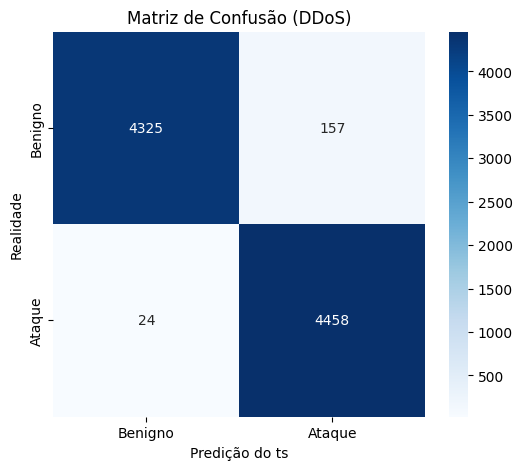

In [20]:
ts.eval()                                               # Coloca o modelo em modo de avaliação
with torch.no_grad():                                   # Evita o cálculo de gradientes durante a avaliação
    y_pred_prob = ts(X_test)                            # Predição das probabilidades
    y_pred_class = (y_pred_prob >= 0.5).float()         # Classificação com threshold de 0.8
    
y_real = y_test.numpy()                                 # Conversão dos tensores para numpy arrays
y_pred = y_pred_class.numpy()

acc = accuracy_score(y_real, y_pred)
print(f'Acurácia Global: {acc:.4f}')
print("-" * 30)

prec_benigno = precision_score(y_real, y_pred, pos_label=0)
rec_benigno = recall_score(y_real, y_pred, pos_label=0)
f1_benigno = f1_score(y_real, y_pred, pos_label=0)

print("CLASSE BENIGNO (0):")
print(f"  Precisão: {prec_benigno:.4f}")
print(f"  Recall:   {rec_benigno:.4f}")
print(f"  F1-Score: {f1_benigno:.4f}")
print("-" * 30)

prec_ataque = precision_score(y_real, y_pred, pos_label=1)
rec_ataque = recall_score(y_real, y_pred, pos_label=1)
f1_ataque = f1_score(y_real, y_pred, pos_label=1)

print("CLASSE ATAQUE (1):")
print(f"  Precisão: {prec_ataque:.4f}")
print(f"  Recall:   {rec_ataque:.4f}")
print(f"  F1-Score: {f1_ataque:.4f}")
print("-" * 30)

cm = confusion_matrix(y_real, y_pred) # Matriz de confusão
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Benigno', 'Ataque'], 
            yticklabels=['Benigno', 'Ataque'])
plt.xlabel('Predição do ts')
plt.ylabel('Realidade')
plt.title('Matriz de Confusão (DDoS)')
plt.show()

--- EXECUTANDO TESTE DE VALIDAÇÃO CRUZADA DIRETA (UNSW-NB15 UDP) ---
Dataset UNSW Importado! Formato da Matriz: (1054, 52)
Distribuição Real das Classes:
Label
0    527
1    527
Name: count, dtype: int64

--- OTIMIZAÇÃO DE FRONTEIRA DE DECISÃO ---
O Limiar ótimo calculado via Índice de Youden para o UNSW é: 0.7344

Acurácia Global no UNSW-NB15: 0.6490
-----------------------------------
CLASSE BENIGNO (0):
  Precisão: 0.6062
  Recall:   0.8501
  F1-Score: 0.7077
-----------------------------------
CLASSE ATAQUE (1):
  Precisão: 0.7492
  Recall:   0.4478
  F1-Score: 0.5606
-----------------------------------


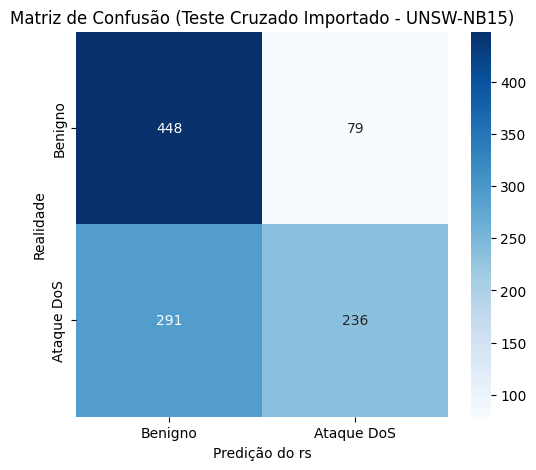

AUC (Área Sob a Curva): 0.5245


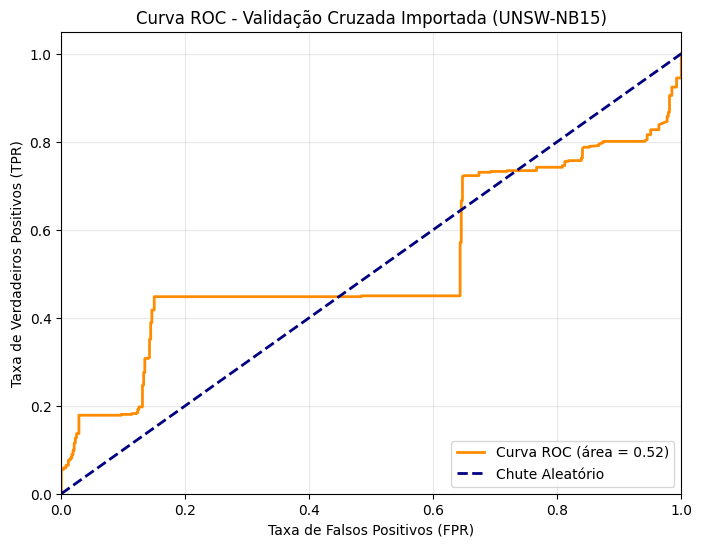

In [21]:

print("--- EXECUTANDO TESTE DE VALIDAÇÃO CRUZADA DIRETA (UNSW-NB15 UDP) ---")

# 1. Definição do caminho do arquivo CSV gerado no passo de exportação
path_saida_unsw = r"C:\Users\xrafa\Downloads\archive\UNSW_UDP_Validacao.csv"

# 2. Importar o Dataset de Validação já estruturado com as 59 colunas + Label
df_validacao = pd.read_csv(path_saida_unsw)

print(f"Dataset UNSW Importado! Formato da Matriz: {df_validacao.shape}")
print(f"Distribuição Real das Classes:\n{df_validacao['Label'].value_counts()}\n")

# 3. Separação da matriz de características e rótulos reais
X_unsw_raw = df_validacao.drop('Label', axis=1).values.astype(np.float32)
y_unsw_real = df_validacao['Label'].values.astype(np.float32)

# 4. Aplicação do StandardScaler Global (utilizando o objeto carregado do treino do CIC)
X_unsw_scaled = scaler_global.transform(X_unsw_raw)

# 5. Conversão em Tensor do PyTorch
X_unsw_tensor = torch.tensor(X_unsw_scaled, dtype=torch.float32)

# ==============================================================================
# --- EXECUÇÃO DA PREDIÇÃO COM MODELO (rs) ---
# ==============================================================================
ts.eval() 
with torch.no_grad():
    y_pred_unsw = ts(X_unsw_tensor) 
    y_probs_unsw = y_pred_unsw.numpy().flatten()

# --- BLINDAGEM CONTRA NaNs: Corrige estouros de limite causados pelo StandardScaler ---
if np.isnan(y_probs_unsw).any():
    qtd_nans = np.isnan(y_probs_unsw).sum()
    print(f"⚠️ Alerta: Detectados {qtd_nans} valores NaN gerados pela rede.")
    print("Substituindo NaNs por 0.0 (Benigno) para evitar travamento da Curva ROC...")
    y_probs_unsw = np.nan_to_num(y_probs_unsw, nan=0.0)

# ==============================================================================
# --- OTIMIZAÇÃO DE FRONTEIRA DE DECISÃO (ÍNDICE DE YOUDEN) ---
# ==============================================================================
fpr, tpr, thresholds = roc_curve(y_unsw_real.flatten(), y_probs_unsw)

j_scores = tpr - fpr
best_idx = np.argmax(j_scores)
best_threshold = thresholds[best_idx]

print(f"--- OTIMIZAÇÃO DE FRONTEIRA DE DECISÃO ---")
print(f"O Limiar ótimo calculado via Índice de Youden para o UNSW é: {best_threshold:.4f}\n")

# Aplicação do ponto de corte adaptativo otimizado
y_pred_unsw_flat = (y_probs_unsw >= best_threshold).astype(np.float32)

# ==============================================================================
# --- EXIBIÇÃO DE MÉTRICAS FORMATADAS ---
# ==============================================================================
acc_unsw = accuracy_score(y_unsw_real, y_pred_unsw_flat)
print(f'Acurácia Global no UNSW-NB15: {acc_unsw:.4f}')
print("-" * 35)

# Métricas Classe Benigna
prec_b = precision_score(y_unsw_real, y_pred_unsw_flat, pos_label=0, zero_division=0)
rec_b = recall_score(y_unsw_real, y_pred_unsw_flat, pos_label=0, zero_division=0)
f1_b = f1_score(y_unsw_real, y_pred_unsw_flat, pos_label=0, zero_division=0)

print("CLASSE BENIGNO (0):")
print(f"  Precisão: {prec_b:.4f}")
print(f"  Recall:   {rec_b:.4f}")
print(f"  F1-Score: {f1_b:.4f}")
print("-" * 35)

# Métricas Classe Ataque
prec_a = precision_score(y_unsw_real, y_pred_unsw_flat, pos_label=1, zero_division=0)
rec_a = recall_score(y_unsw_real, y_pred_unsw_flat, pos_label=1, zero_division=0)
f1_a = f1_score(y_unsw_real, y_pred_unsw_flat, pos_label=1, zero_division=0)

print("CLASSE ATAQUE (1):")
print(f"  Precisão: {prec_a:.4f}")
print(f"  Recall:   {rec_a:.4f}")
print(f"  F1-Score: {f1_a:.4f}")
print("-" * 35)

# ==============================================================================
# --- PLOT: MATRIZ DE CONFUSÃO (SEABORN) ---
# ==============================================================================
cm_unsw = confusion_matrix(y_unsw_real, y_pred_unsw_flat) 

plt.figure(figsize=(6, 5))
sns.heatmap(cm_unsw, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Benigno', 'Ataque DoS'], 
            yticklabels=['Benigno', 'Ataque DoS'])
plt.xlabel('Predição do rs')
plt.ylabel('Realidade')
plt.title('Matriz de Confusão (Teste Cruzado Importado - UNSW-NB15)')
plt.show()

# ==============================================================================
# --- PLOT: CURVA ROC ---
# ==============================================================================
roc_auc = auc(fpr, tpr)
print(f'AUC (Área Sob a Curva): {roc_auc:.4f}') 

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Curva ROC (área = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Chute Aleatório')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taxa de Falsos Positivos (FPR)')
plt.ylabel('Taxa de Verdadeiros Positivos (TPR)')
plt.title('Curva ROC - Validação Cruzada Importada (UNSW-NB15)')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()